In [7]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download('nelgiriyewithana/emotions')
df = pd.read_csv(path + '/text.csv')

print(df.shape)
print('Path to dataset files:', path)

(416809, 3)
Path to dataset files: /home/jens/.cache/kagglehub/datasets/nelgiriyewithana/emotions/versions/1


In [8]:
df.describe()

,Unnamed: 0,label
count,416809.000000,416809.000000
mean,208404.000000,1.554271
std,120322.538513,1.490453
min,0.000000,0.000000
25%,104202.000000,0.000000
50%,208404.000000,1.000000
75%,312606.000000,3.000000
max,416808.000000,5.000000


In [9]:
df.sample(5, random_state=42)

,Unnamed: 0,text,label
36130,36130,id say maybe made them feel foolish but that w...,0
138065,138065,i joined the lds church i admit to feeling som...,0
146440,146440,i must admit i didnt feel like hugging him not...,3
103337,103337,i hate that i can still feel if any nerve is d...,0
315528,315528,im actually feeling a little smug,1


In [10]:
EMOTION_MAP = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

df['emotion_name'] = df['label'].map(EMOTION_MAP)

print('Label counts:')
print(df['emotion_name'].value_counts())
print()
print('Unique emotions:', df['emotion_name'].unique())

Label counts:
emotion_name
joy         141067
sadness     121187
anger        57317
fear         47712
love         34554
surprise     14972
Name: count, dtype: int64

Unique emotions: <StringArray>
['fear', 'sadness', 'love', 'joy', 'surprise', 'anger']
Length: 6, dtype: str


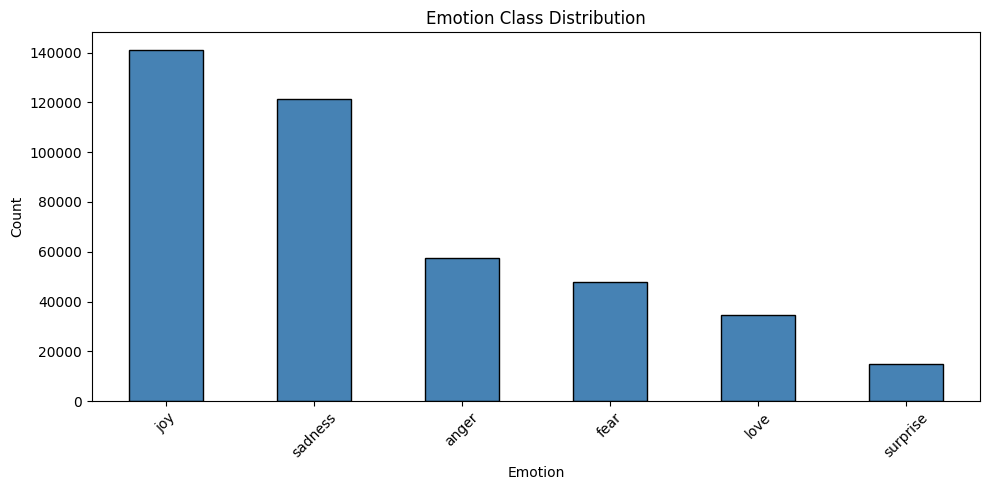

In [11]:
import matplotlib.pyplot as plt

df['emotion_name'].value_counts().plot(kind='bar', figsize=(10, 5), color='steelblue', edgecolor='black')
plt.title('Emotion Class Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
print('Before cleaning:', df.shape)
clean_df = df.copy().dropna(subset=['text', 'label'])
clean_df.drop_duplicates(subset=['text'], inplace=True)
print('After cleaning:', clean_df.shape)
clean_df.head(5)

Before cleaning: (416809, 4)
After cleaning: (393822, 4)


,Unnamed: 0,text,label,emotion_name
0,0,i just feel really helpless and heavy hearted,4,fear
1,1,ive enjoyed being able to slouch about relax a...,0,sadness
2,2,i gave up my internship with the dmrg and am f...,4,fear
3,3,i dont know i feel so lost,0,sadness
4,4,i am a kindergarten teacher and i am thoroughl...,4,fear


In [13]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    sanitized_text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    sanitized_text = sanitized_text.lower()
    split_text = sanitized_text.split()
    text_without_stopwords = [word for word in split_text if word not in stop_words]
    lemmatized_text = [lemmatizer.lemmatize(word) for word in text_without_stopwords]
    return ' '.join(lemmatized_text)

clean_df['text'] = clean_df['text'].apply(preprocess_text)
clean_df.head(5)

[nltk_data] Downloading package stopwords to /home/jens/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jens/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,Unnamed: 0,text,label,emotion_name
0,0,feel really helpless heavy hearted,4,fear
1,1,ive enjoyed able slouch relax unwind frankly n...,0,sadness
2,2,gave internship dmrg feeling distraught,4,fear
3,3,dont know feel lost,0,sadness
4,4,kindergarten teacher thoroughly weary job take...,4,fear


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000)
tfidf_matrix = vectorizer.fit_transform(clean_df['text'])

# TF-IDF = Term Frequency * Inverse Document Frequency
print('Shape of TF-IDF matrix:', tfidf_matrix.shape)

Shape of TF-IDF matrix: (393822, 10000)


In [15]:
from sklearn.model_selection import train_test_split

x = tfidf_matrix
y = clean_df['label'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)

y_pred = model.predict(x_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy:  {accuracy  * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall:    {recall    * 100:.2f}%')
print(f'F1-score:  {f1        * 100:.2f}%')
print()
print('Classification Report:')
emotion_names = [EMOTION_MAP[i] for i in sorted(EMOTION_MAP.keys())]
print(classification_report(y_test, y_pred, target_names=emotion_names))

Accuracy:  93.38%
Precision: 93.34%
Recall:    93.38%
F1-score:  93.35%

Classification Report:
              precision    recall  f1-score   support

     sadness       0.95      0.95      0.95     23702
         joy       0.94      0.96      0.95     27006
        love       0.89      0.85      0.87      5894
       anger       0.93      0.92      0.93     10956
        fear       0.91      0.90      0.90      8726
    surprise       0.87      0.81      0.84      2481

    accuracy                           0.93     78765
   macro avg       0.91      0.90      0.91     78765
weighted avg       0.93      0.93      0.93     78765



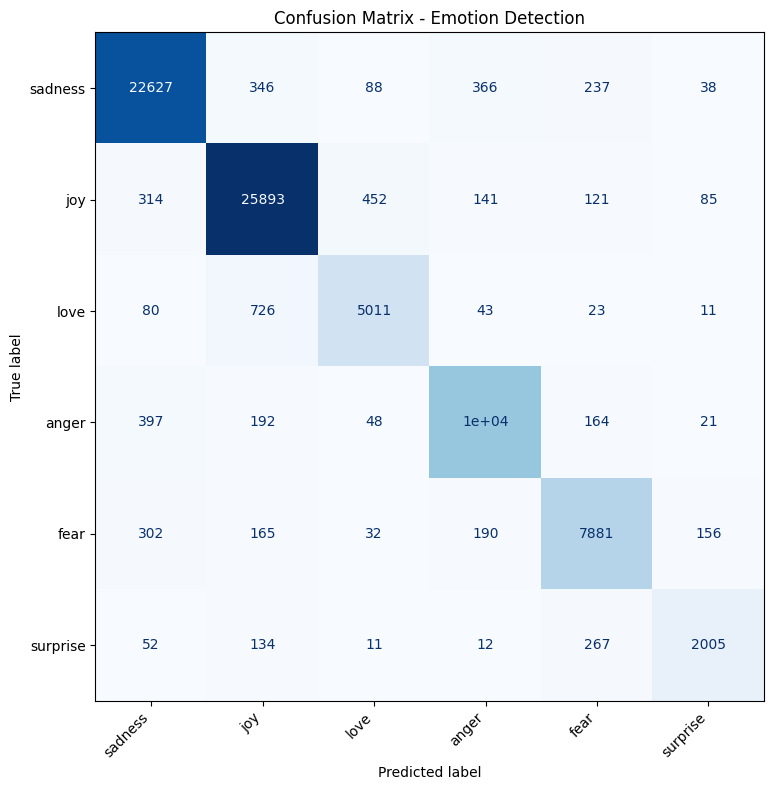

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Emotion Detection')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
import joblib
from sklearn.pipeline import Pipeline

joblib.dump(model, f'emotion_model_acc_{accuracy * 100:.2f}%.pkl')

# Save full inference pipeline (vectorizer + model)
pipeline = Pipeline([
    ('tfidf', vectorizer),
    ('clf',   model)
])
joblib.dump(pipeline, f'emotion_pipeline.pkl')
joblib.dump(pipeline, f'emotion_pipeline_acc_{accuracy * 100:.2f}%.pkl')

print('Models saved.')

Models saved.


In [20]:
def predict_emotion(text: str) -> str:
    cleaned = preprocess_text(text)
    label = pipeline.predict([cleaned])[0]
    return EMOTION_MAP[label]

samples = [
    'I am so happy today, everything is going great!',
    'I feel absolutely devastated and cannot stop crying.',
    'This makes me so angry, I cannot believe it happened.',
    'I am really scared about what might happen next.',
    'Wow, I never expected that to happen!',
    'I love spending time with the people I care about.',
]

print('Emotion Predictions:')
print('--------------------------------------')
for s in samples:
    print(f'Text:    {s}')
    print(f'Emotion: {predict_emotion(s)}')
    print()

Emotion Predictions:
--------------------------------------
Text:    I am so happy today, everything is going great!
Emotion: joy

Text:    I feel absolutely devastated and cannot stop crying.
Emotion: sadness

Text:    This makes me so angry, I cannot believe it happened.
Emotion: anger

Text:    I am really scared about what might happen next.
Emotion: fear

Text:    Wow, I never expected that to happen!
Emotion: sadness

Text:    I love spending time with the people I care about.
Emotion: joy

